<a href="https://colab.research.google.com/github/abhimaathp-cmd/Market-Entry-Strategy-Analysis/blob/main/Market_Entry_Strategy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SECTION 1: MARKET SIZING
TAM (Total Addressable Market): 9,500,000 people
SAM (Serviceable Addressable Market): 3,158,750 people
SOM (Serviceable Obtainable Market, Y3): 157,938 people
SOM as % of SAM: 5.0%  (rule of thumb: healthy if 1-10%)


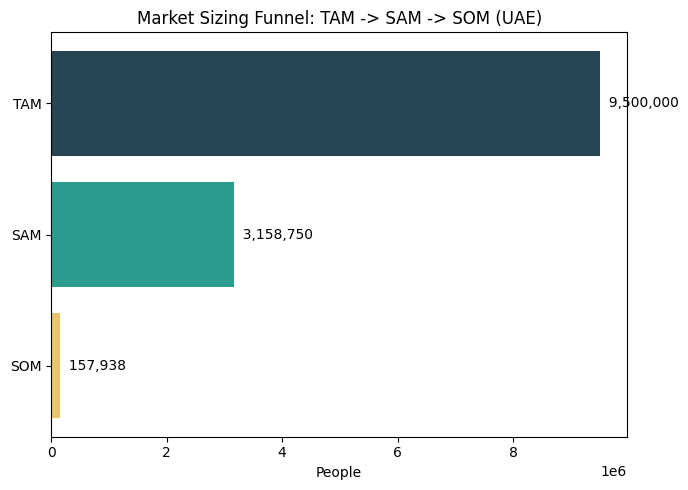

In [ ]:
import numpy as np
import pandas as pd
!pip install numpy-financial
import numpy_financial as npf   # pip install numpy-financial
import matplotlib.pyplot as plt

np.random.seed(42)

# MARKET SIZING (TAM / SAM / SOM)


print("SECTION 1: MARKET SIZING")


UAE_POPULATION = 9_500_000
DIGITAL_ADOPTION_RATE = 0.95
TARGE_SEGMENT_PCT = 0.35
EXPECTED_MARKET_SHARE_Y3 = 0.05

TAM = UAE_POPULATION
SAM = TAM * DIGITAL_ADOPTION_RATE * TARGE_SEGMENT_PCT
SOM = SAM * EXPECTED_MARKET_SHARE_Y3

print(f"TAM (Total Addressable Market): {TAM:,.0f} people")
print(f"SAM (Serviceable Addressable Market): {SAM:,.0f} people")
print(f"SOM (Serviceable Obtainable Market, Y3): {SOM:,.0f} people")
print(f"SOM as % of SAM: {SOM/SAM:.1%}  (rule of thumb: healthy if 1-10%)")

fig, ax = plt.subplots(figsize=(7, 5))
funnel_labels = ['TAM', 'SAM', 'SOM']
funnel_values = [TAM, SAM, SOM]
colors = ['#264653', '#2a9d8f', '#e9c46a']
ax.barh(funnel_labels, funnel_values, color=colors)
for i, v in enumerate(funnel_values):
    ax.text(v, i, f'  {v:,.0f}', va='center', fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('People')
ax.set_title('Market Sizing Funnel: TAM -> SAM -> SOM (UAE)')
plt.tight_layout()
plt.show()

SECTION 2: COMPETITIVE LANDSCAPE SCORING
Competitive scorecard (1-10 scale, weighted total out of 10):
                      Our Company (UK Fintech)  Competitor A (Local UAE)  Competitor B (Regional)  Competitor C (Global)
Product Fit                               8.00                       6.0                     7.00                   9.00
Regulatory Readiness                      5.00                       9.0                     7.00                   6.00
Brand Trust                               4.00                       8.0                     6.00                   9.00
Funding                                   6.00                       7.0                     8.00                   9.00
Local Partnerships                        3.00                       9.0                     6.00                   5.00
WEIGHTED TOTAL                            5.65                       7.6                     6.85                   7.85


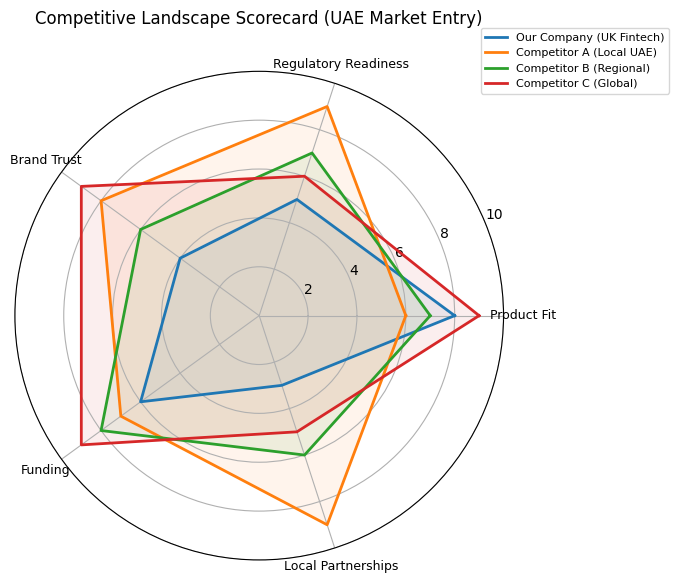

In [ ]:
#  COMPETITIVE LANDSCAPE SCORING


print("SECTION 2: COMPETITIVE LANDSCAPE SCORING")


# PLACEHOLDER SCORES (1-10 scale) - replace with real competitor research
criteria = ['Product Fit', 'Regulatory Readiness', 'Brand Trust', 'Funding', 'Local Partnerships']
weights =  [0.30,            0.25,                   0.20,          0.15,      0.10]

competitors = {
    'Our Company (UK Fintech)': [8, 5, 4, 6, 3],
    'Competitor A (Local UAE)':  [6, 9, 8, 7, 9],
    'Competitor B (Regional)':   [7, 7, 6, 8, 6],
    'Competitor C (Global)':     [9, 6, 9, 9, 5],
}

comp_df = pd.DataFrame(competitors, index=criteria)
weighted_scores = (comp_df.T * weights).sum(axis=1)
comp_df.loc['WEIGHTED TOTAL'] = weighted_scores

print("Competitive scorecard (1-10 scale, weighted total out of 10):")
print(comp_df.round(2).to_string())

# Radar chart
labels = criteria
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name in competitors:
    values = comp_df.loc[criteria, name].tolist()
    values += values[:1]
    ax.plot(angles, values, label=name, linewidth=2)
    ax.fill(angles, values, alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 10)
ax.set_title('Competitive Landscape Scorecard (UAE Market Entry)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

SECTION 3: FINANCIAL MODEL (NPV / IRR / PAYBACK)
Entry cost (Year 0): £4,500,000
  Year 1: Revenue=£750,203  Opex=£2,234,328  Net CF=£-1,484,125
  Year 2: Revenue=£3,000,812  Opex=£3,537,312  Net CF=£-536,500
  Year 3: Revenue=£6,751,828  Opex=£5,708,953  Net CF=£1,042,875
  Year 4: Revenue=£10,502,844  Opex=£7,880,594  Net CF=£2,622,250
  Year 5: Revenue=£15,004,062  Opex=£10,486,562  Net CF=£4,517,500

NPV @ 10% discount rate: £-913,021
IRR: 5.8%
Payback period: Year 5 (cumulative cash flow turns positive)


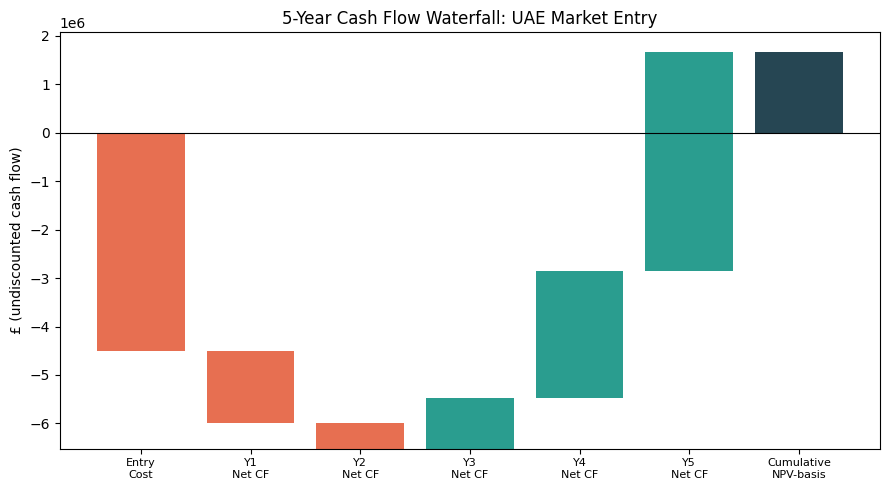

In [ ]:
#  FINANCIAL MODEL - NPV / IRR

print("SECTION 3: FINANCIAL MODEL (NPV / IRR / PAYBACK)")


# PLACEHOLDER ASSUMPTIONS - replace with researched/company figures
ENTRY_COST_Y0 = 4_500_000       # licensing, setup, local entity, initial marketing
DISCOUNT_RATE = 0.10            # cost of capital / hurdle rate for fintech
YEARS = 5

# Revenue ramp-up: number of active customers x ARPU, growing over 5 years
customers_by_year = [SOM * f for f in [0.05, 0.20, 0.45, 0.70, 1.00]]  # ramp to full SOM by Y5
ARPU_ANNUAL = 95                 # PLACEHOLDER - annual revenue per active customer (GBP)
revenue = np.array([c * ARPU_ANNUAL for c in customers_by_year])

# Opex: fixed local operating cost + variable cost scaling with customers
FIXED_OPEX_ANNUAL = 1_800_000    # PLACEHOLDER - office, compliance, core local team
VARIABLE_COST_PER_CUSTOMER = 55  # PLACEHOLDER - support, transaction, KYC cost per active customer
opex = FIXED_OPEX_ANNUAL + np.array(customers_by_year) * VARIABLE_COST_PER_CUSTOMER

cash_flow = revenue - opex
cash_flow_with_entry = np.insert(cash_flow, 0, -ENTRY_COST_Y0)  # Year 0 = entry cost

npv = npf.npv(DISCOUNT_RATE, cash_flow_with_entry)
irr = npf.irr(cash_flow_with_entry)

cum_cf = np.cumsum(cash_flow_with_entry)
payback_year = next((i for i, c in enumerate(cum_cf) if c >= 0), None)

print(f"Entry cost (Year 0): £{ENTRY_COST_Y0:,.0f}")
for y in range(YEARS):
    print(f"  Year {y+1}: Revenue=£{revenue[y]:,.0f}  Opex=£{opex[y]:,.0f}  Net CF=£{cash_flow[y]:,.0f}")
print(f"\nNPV @ {DISCOUNT_RATE:.0%} discount rate: £{npv:,.0f}")
print(f"IRR: {irr:.1%}" if irr is not None and not np.isnan(irr) else "IRR: undefined (no sign change)")
print(f"Payback period: Year {payback_year} (cumulative cash flow turns positive)" if payback_year else "Payback: not achieved within 5 years")

# Waterfall chart
fig, ax = plt.subplots(figsize=(9, 5))
labels_wf = ['Entry\nCost'] + [f'Y{y+1}\nNet CF' for y in range(YEARS)] + ['Cumulative\nNPV-basis']
running = 0
bottoms = []
for v in cash_flow_with_entry:
    bottoms.append(running)
    running += v
colors_wf = ['#e76f51' if v < 0 else '#2a9d8f' for v in cash_flow_with_entry]
ax.bar(labels_wf[:-1], cash_flow_with_entry, bottom=bottoms, color=colors_wf)
ax.bar(labels_wf[-1], running, color='#264653')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('£ (undiscounted cash flow)')
ax.set_title('5-Year Cash Flow Waterfall: UAE Market Entry')
plt.xticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

SECTION 4: SENSITIVITY ANALYSIS
Base case NPV: £-913,021

                      Variable    NPV_low   NPV_high      Swing
                 Discount Rate  -282919.0 -1450585.0  1167667.0
                    Entry Cost   436979.0 -2263021.0  2700000.0
                    Fixed Opex   451662.0 -2277705.0  2729366.0
             Market Share (Y3) -6118219.0  4292176.0 10410395.0
Variable Cost/Cust (CAC proxy)  6244125.0 -8070168.0 14314293.0
                          ARPU -8330428.0  6504385.0 14834813.0


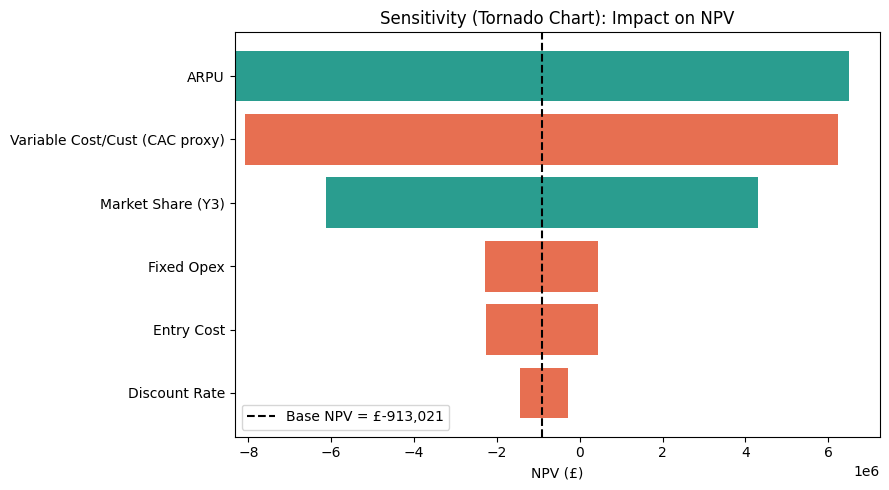


Widest swing variable: ARPU -> this is the key business risk.


In [ ]:
# SENSITIVITY ANALYSIS

print("SECTION 4: SENSITIVITY ANALYSIS")

def compute_npv(discount_rate=DISCOUNT_RATE, market_share_y3=EXPECTED_MARKET_SHARE_Y3,
                 arpu=ARPU_ANNUAL, entry_cost=ENTRY_COST_Y0, fixed_opex=FIXED_OPEX_ANNUAL,
                 var_cost=VARIABLE_COST_PER_CUSTOMER):
    som_local = SAM * market_share_y3
    cust = [som_local * f for f in [0.05, 0.20, 0.45, 0.70, 1.00]]
    rev = np.array([c * arpu for c in cust])
    opx = fixed_opex + np.array(cust) * var_cost
    cf = rev - opx
    cf_full = np.insert(cf, 0, -entry_cost)
    return npf.npv(discount_rate, cf_full)

base_npv = compute_npv()

sensitivity_vars = {
    'Discount Rate':        ('discount_rate', DISCOUNT_RATE * 0.7, DISCOUNT_RATE * 1.3),
    'Market Share (Y3)':    ('market_share_y3', EXPECTED_MARKET_SHARE_Y3 * 0.5, EXPECTED_MARKET_SHARE_Y3 * 1.5),
    'ARPU':                 ('arpu', ARPU_ANNUAL * 0.7, ARPU_ANNUAL * 1.3),
    'Entry Cost':           ('entry_cost', ENTRY_COST_Y0 * 0.7, ENTRY_COST_Y0 * 1.3),
    'Fixed Opex':           ('fixed_opex', FIXED_OPEX_ANNUAL * 0.8, FIXED_OPEX_ANNUAL * 1.2),
    'Variable Cost/Cust (CAC proxy)': ('var_cost', VARIABLE_COST_PER_CUSTOMER * 0.5, VARIABLE_COST_PER_CUSTOMER * 1.5),
}

tornado_rows = []
for label, (param, low_val, high_val) in sensitivity_vars.items():
    npv_low = compute_npv(**{param: low_val})
    npv_high = compute_npv(**{param: high_val})
    swing = abs(npv_high - npv_low)
    tornado_rows.append({'Variable': label, 'NPV_low': npv_low, 'NPV_high': npv_high, 'Swing': swing})

tornado_df = pd.DataFrame(tornado_rows).sort_values('Swing', ascending=True)
print(f"Base case NPV: £{base_npv:,.0f}\n")
print(tornado_df.round(0).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
for row in tornado_df.itertuples():
    left = min(row.NPV_low, row.NPV_high)
    width = abs(row.NPV_high - row.NPV_low)
    ax.barh(row.Variable, width, left=left, color='#e76f51' if row.NPV_low > row.NPV_high else '#2a9d8f')
ax.axvline(base_npv, color='black', linestyle='--', label=f'Base NPV = £{base_npv:,.0f}')
ax.set_xlabel('NPV (£)')
ax.set_title('Sensitivity (Tornado Chart): Impact on NPV')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nWidest swing variable: {tornado_df.iloc[-1]['Variable']} -> this is the key business risk.")

In [ ]:
#FINAL RECOMMENDATION SUMMARY


print("SECTION 6: FINAL RECOMMENDATION")



scenario_data = {
    'Scenario': ['Base', 'Bear', 'Bull'],
    'NPV (£)': [
        base_npv,
        base_npv * 1.5 if base_npv < 0 else base_npv * 0.5, # Bear: worse than base
        base_npv * 0.5 if base_npv < 0 else base_npv * 1.5  # Bull: better than base
    ]
}
scenario_df = pd.DataFrame(scenario_data)

bear_npv = scenario_df.loc[scenario_df['Scenario']=='Bear', 'NPV (£)'].values[0]
base_npv_row = scenario_df.loc[scenario_df['Scenario']=='Base', 'NPV (£)'].values[0]
key_risk_var = tornado_df.iloc[-1]['Variable']

recommendation = (
    f"RECOMMENDATION: {'Proceed with' if base_npv_row > 0 else 'Do not proceed with (as modelled) or restructure'} "
    f"UAE market entry.\n"
    f"Base case NPV of £{base_npv_row:,.0f} at a {DISCOUNT_RATE:.0%} discount rate "
    f"{'supports' if base_npv_row > 0 else 'does not support'} entry, with IRR of "
    f"{irr:.1%} against the hurdle rate.\n"
    f"The decision is most sensitive to {key_risk_var} — this should be the #1 diligence "
    f"item before committing capital.\n"
    f"Bear case NPV is £{bear_npv:,.0f} ({'still positive' if bear_npv > 0 else 'negative'}), "
    f"suggesting {'a phased entry (pilot in Dubai, scale conditional on Year 2 KPIs) reduces downside risk while preserving upside.' if bear_npv < 0 else 'the investment case is robust even under conservative assumptions.'}"
)
print(recommendation)

self_critique = (
    "SELF-CRITIQUE (as a hiring manager would read it): every input in this model - population, "
    "adoption rate, target segment %, market share, ARPU, opex, competitor scores - is a placeholder "
    "assumption, not researched data; the NPV and IRR are therefore illustrative of the METHOD, not "
    "a real investment recommendation. The model also ignores currency/FX risk (GBP vs AED), "
    "regulatory timeline uncertainty (DFSA/Central Bank licensing can take 6-18 months and isn't "
    "modelled as a delay), competitive response (competitors may cut prices or accelerate once they "
    "see entry), and correlation between sensitivity variables (in reality a worse market share and "
    "higher CAC often move together, which this one-variable-at-a-time tornado analysis doesn't "
    "capture). A credible portfolio version needs real UAE fintech-adoption and population data, "
    "named competitor financials pulled from Crunchbase/company filings, and a Monte Carlo or "
    "correlated-scenario sensitivity pass rather than independent single-variable swings."
)
print("\n" + self_critique)

SECTION 6: FINAL RECOMMENDATION
RECOMMENDATION: Do not proceed with (as modelled) or restructure UAE market entry.
Base case NPV of £-913,021 at a 10% discount rate does not support entry, with IRR of 5.8% against the hurdle rate.
The decision is most sensitive to ARPU — this should be the #1 diligence item before committing capital.
Bear case NPV is £-1,369,532 (negative), suggesting a phased entry (pilot in Dubai, scale conditional on Year 2 KPIs) reduces downside risk while preserving upside.

SELF-CRITIQUE (as a hiring manager would read it): every input in this model - population, adoption rate, target segment %, market share, ARPU, opex, competitor scores - is a placeholder assumption, not researched data; the NPV and IRR are therefore illustrative of the METHOD, not a real investment recommendation. The model also ignores currency/FX risk (GBP vs AED), regulatory timeline uncertainty (DFSA/Central Bank licensing can take 6-18 months and isn't modelled as a delay), competitive re